In [1]:
%load_ext watermark


In [2]:
import os
import urllib

os.environ["POLARS_FORCE_NEW_STREAMING"] = "1"

from IPython.display import display, HTML
import pandas as pd
import polars as pl
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from pylib._calc_compsummary_stats import calc_compsummary_stats
from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-05-19T18:46:50.622461+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1027-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

seaborn: 0.13.2
teeplot: 1.4.2
polars : 1.29.0
pandas : 2.2.3

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-05-19-compscreen-multistrain-summary"
teeplot_subdir


'2025-05-19-compscreen-multistrain-summary'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
data_sources = {
    # "uk": "https://osf.io/4asyw/download",
    "multistrain": "https://osf.io/u6ta9/download",
    # "vanilla": "https://osf.io/aysxt/download",
    # "vanilla-big": "https://osf.io/ry5nd/download",
}
tmp_path = "/tmp/data.pqt"


In [7]:
results = []

for source_name, url in data_sources.items():
    print(f"Downloading {source_name} data from {url}")

    urllib.request.urlretrieve(url, tmp_path)
    print("done!")

    df = pl.scan_parquet(
        tmp_path,
        low_memory=True,
        retries=5,
    )

    unique_groups = (
        df.unique(
            [
                "trt_name",
                "trt_n_downsample",
                "trt_hsurf_bits",
                "replicate_uuid",
            ]
        )
        .select(
            pl.col("trt_name"),
            pl.col("trt_n_downsample"),
            pl.col("trt_hsurf_bits"),
            pl.col("replicate_uuid"),
        )
        .drop_nans()
        .drop_nulls()
        .collect(engine="streaming")
    )

    for (trt_name, trt_n_downsample, trt_hsurf_bits, replicate_uuid) in tqdm(
        [*unique_groups.iter_rows()],
    ):
        group = df.filter(
            (pl.col("trt_name") == trt_name)
            & (pl.col("trt_n_downsample") == trt_n_downsample)
            & (pl.col("trt_hsurf_bits") == trt_hsurf_bits)
            & (pl.col("replicate_uuid") == replicate_uuid)
        ).collect(engine="streaming")

        for y in (
            "defmut_norm_all-num_leaves",
            # "defmut_norm_ot_bin:week-num_leaves",
            # "defmut_norm_ot_bin:fortnight-num_leaves",
            # "defmut_norm_ot_bin:month-num_leaves",
            "defmut_norm_ot_bin:quarter-num_leaves",
            # "defmut_norm_ot_bin:year-num_leaves",
            "defmut_norm_match:variant_flavor-num_leaves",
            "defmut_norm_all-clade_duration",
            # "defmut_norm_ot_bin:week-clade_duration",
            # "defmut_norm_ot_bin:fortnight-clade_duration",
            # "defmut_norm_ot_bin:month-clade_duration",
            "defmut_norm_ot_bin:quarter-clade_duration",
            # "defmut_norm_ot_bin:year-clade_duration",
            "defmut_norm_match:variant_flavor-clade_duration",
        ):
            res = calc_compsummary_stats(
                group.to_pandas(),
                x="is_focal_defmut",
                y=y,
            )
            results.extend(
                {
                    "source_name": source_name,
                    "trt_name": trt_name,
                    "trt_n_downsample": trt_n_downsample,
                    "trt_hsurf_bits": trt_hsurf_bits,
                    "replicate_uuid": replicate_uuid,
                    "y": y,
                    **record,
                }
                for record in res
            )


done!


100%|██████████| 70/70 [06:47<00:00,  5.82s/it]


In [8]:
results_df = pd.DataFrame(results)
results_df


,source_name,trt_name,trt_n_downsample,trt_hsurf_bits,replicate_uuid,y,label,binom_n,binom_k,n,n_boot,p_boot,p_binom,p_mw,u_mw,cliffs_delta,na
0,multistrain,Sben1.1x/Gneu,1000000,0,44d77f4a-9af3-84f2-823c-86c50fd7e0ea,defmut_norm_all-num_leaves,all,2545,1597,2545,10000,0.4970,0.508872,NaN,NaN,NaN,0
1,multistrain,Sben1.1x/Gneu,1000000,0,44d77f4a-9af3-84f2-823c-86c50fd7e0ea,defmut_norm_all-num_leaves,False,2525,1585,2545,10000,0.4949,0.499875,0.512726,25160.0,-0.003564,0
2,multistrain,Sben1.1x/Gneu,1000000,0,44d77f4a-9af3-84f2-823c-86c50fd7e0ea,defmut_norm_all-num_leaves,True,20,12,2545,10000,0.5067,0.691248,0.487415,25340.0,0.003564,0
3,multistrain,Sben1.1x/Gneu,1000000,0,44d77f4a-9af3-84f2-823c-86c50fd7e0ea,defmut_norm_ot_bin:quarter-num_leaves,all,2545,1585,2545,10000,0.4914,0.629140,NaN,NaN,NaN,0
4,multistrain,Sben1.1x/Gneu,1000000,0,44d77f4a-9af3-84f2-823c-86c50fd7e0ea,defmut_norm_ot_bin:quarter-num_leaves,False,2525,1573,2545,10000,0.4982,0.621617,0.570605,24738.0,-0.020277,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,multistrain,Sben1.3x/Gneu,1000000,0,e9b17db2-e0ba-87fa-8db6-08f88976224b,defmut_norm_ot_bin:quarter-clade_duration,False,2363,1526,2520,10000,0.6337,0.725860,0.800970,178942.0,-0.035330,0
1256,multistrain,Sben1.3x/Gneu,1000000,0,e9b17db2-e0ba-87fa-8db6-08f88976224b,defmut_norm_ot_bin:quarter-clade_duration,True,157,115,2520,10000,0.0812,0.018786,0.199066,192049.0,0.035330,0
1257,multistrain,Sben1.3x/Gneu,1000000,0,e9b17db2-e0ba-87fa-8db6-08f88976224b,defmut_norm_match:variant_flavor-clade_duration,all,2520,1641,2520,10000,0.4902,0.509176,NaN,NaN,NaN,0
1258,multistrain,Sben1.3x/Gneu,1000000,0,e9b17db2-e0ba-87fa-8db6-08f88976224b,defmut_norm_match:variant_flavor-clade_duration,False,2363,1526,2520,10000,0.7015,0.716994,0.021169,201039.0,0.083794,0


In [9]:
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_all-")
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_ot_bin:")
results_df["trt_name_"] = results_df["trt_name"].str.replace("/", "\n")


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.png


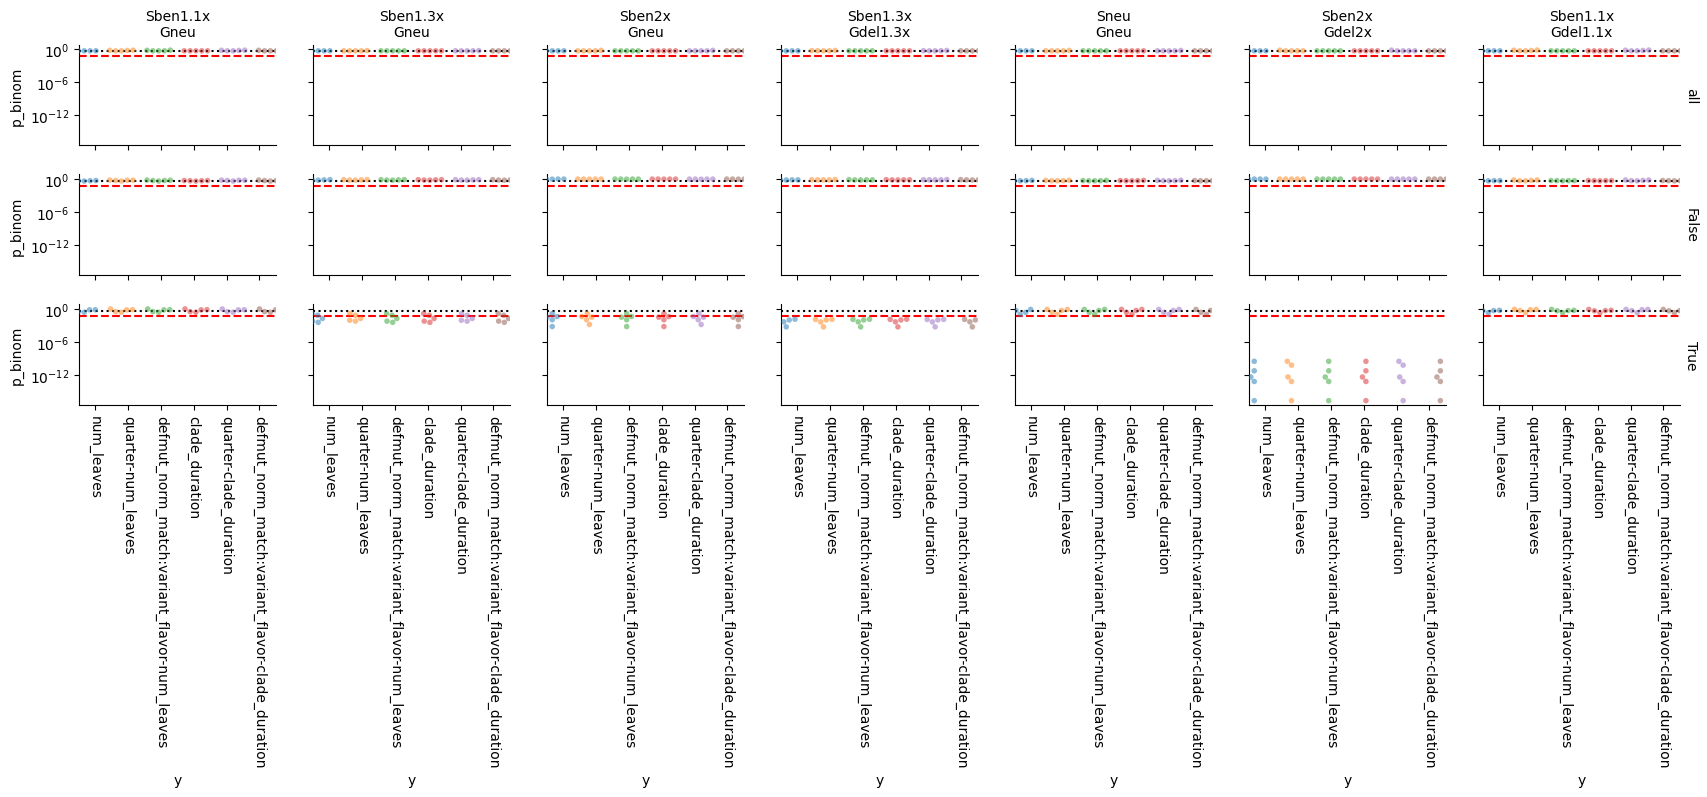

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.png


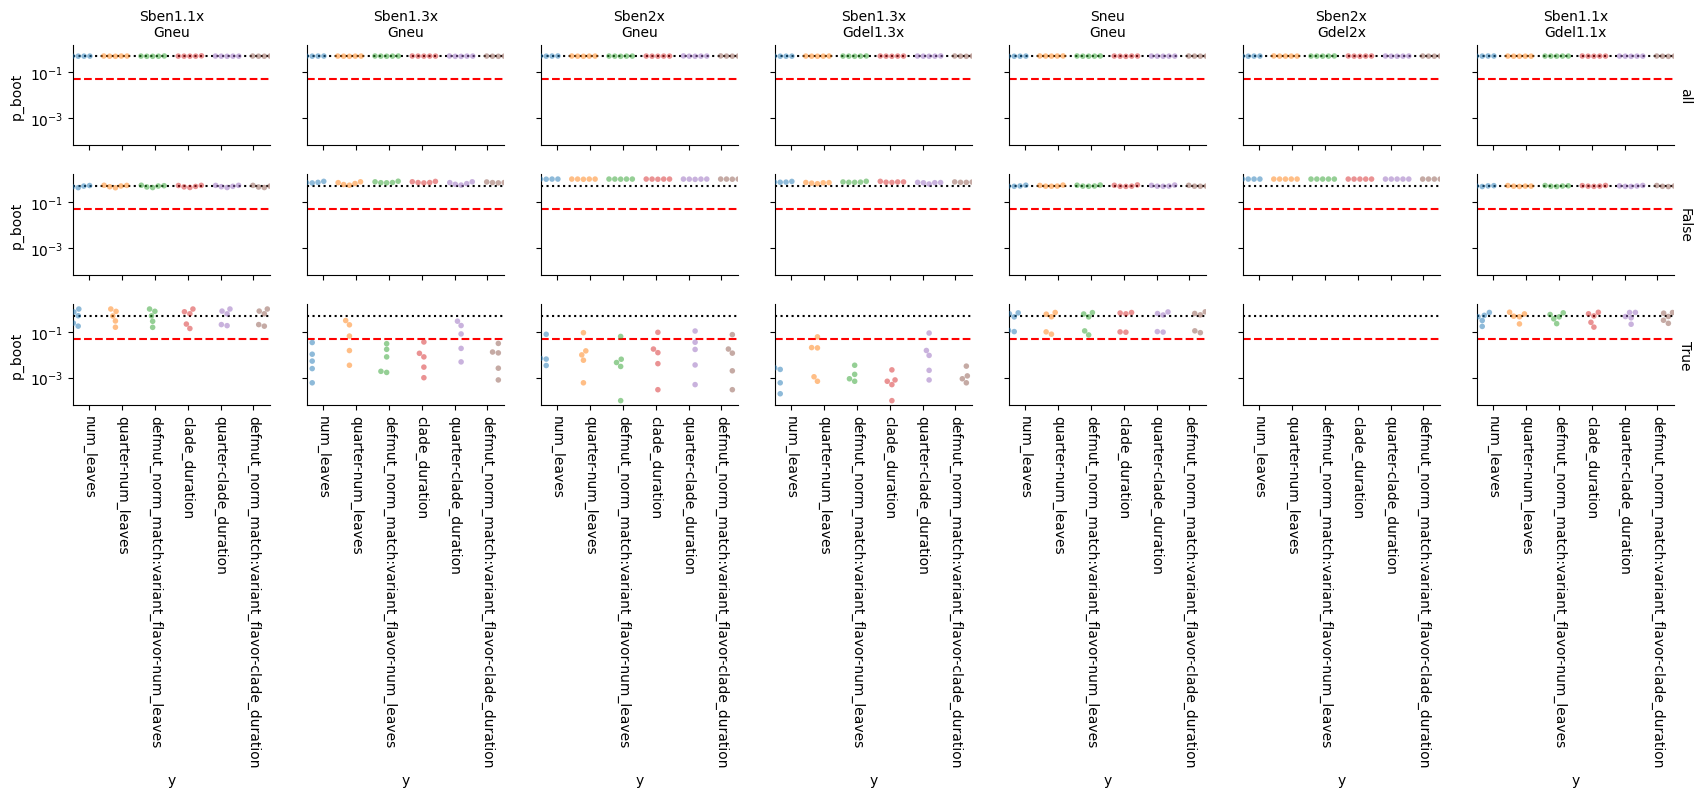

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.png


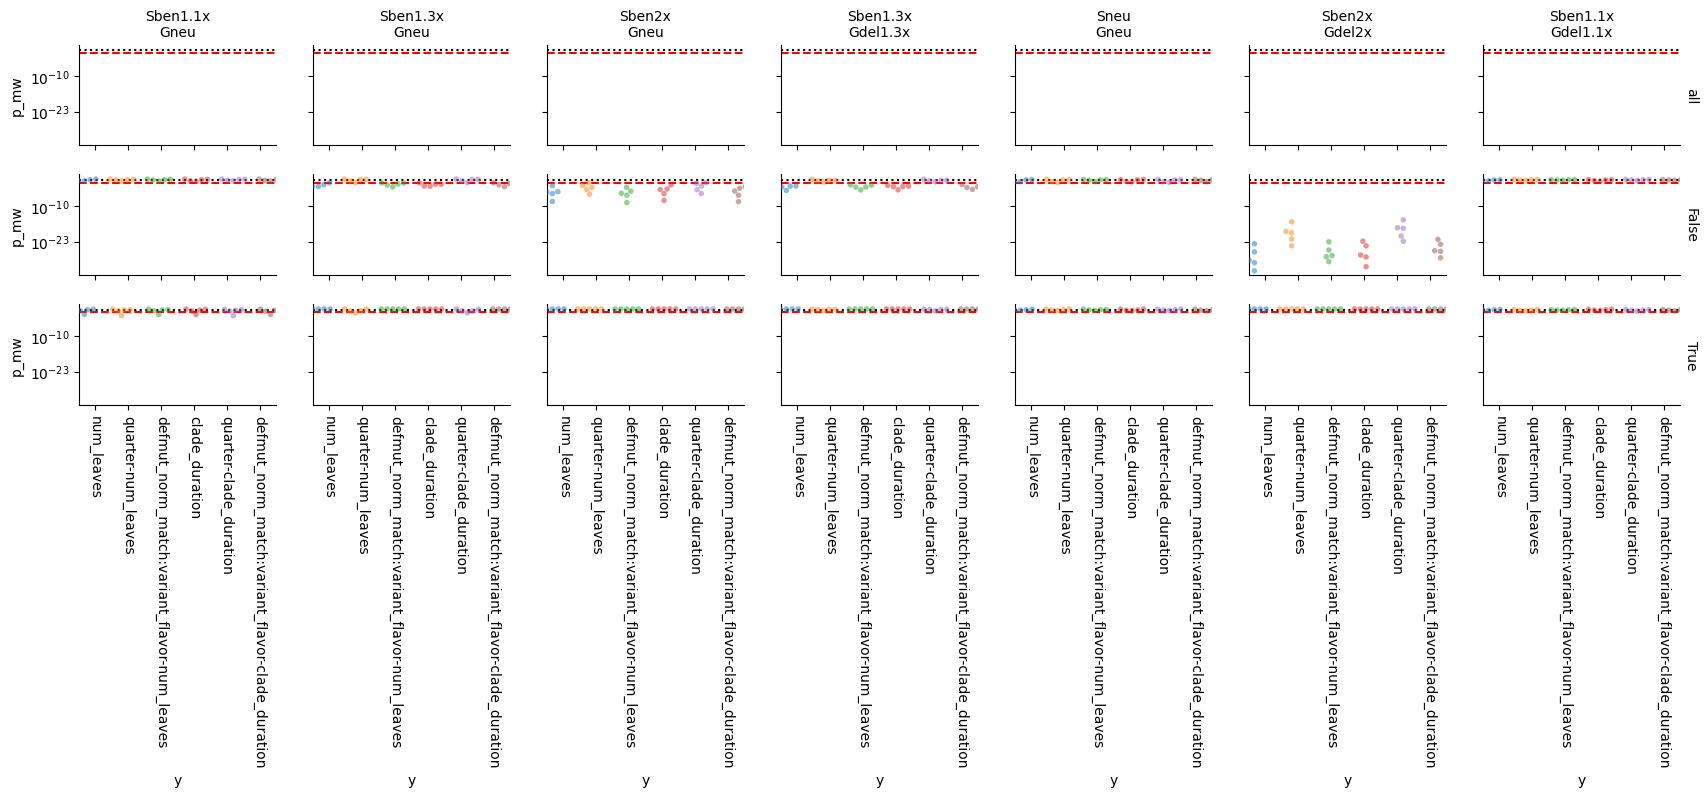

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.png


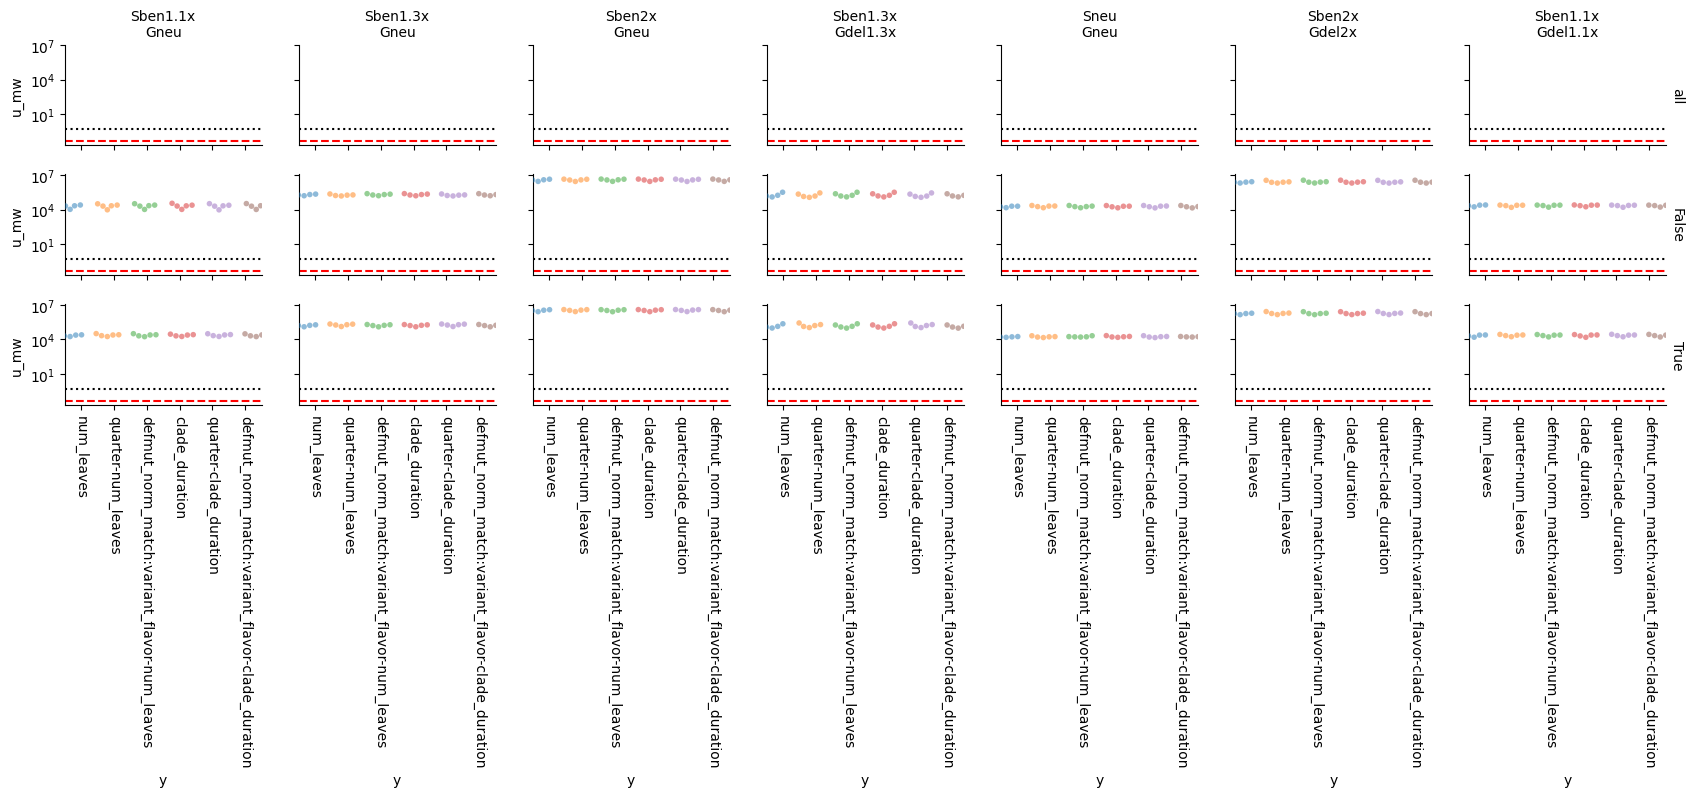

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=y+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.png


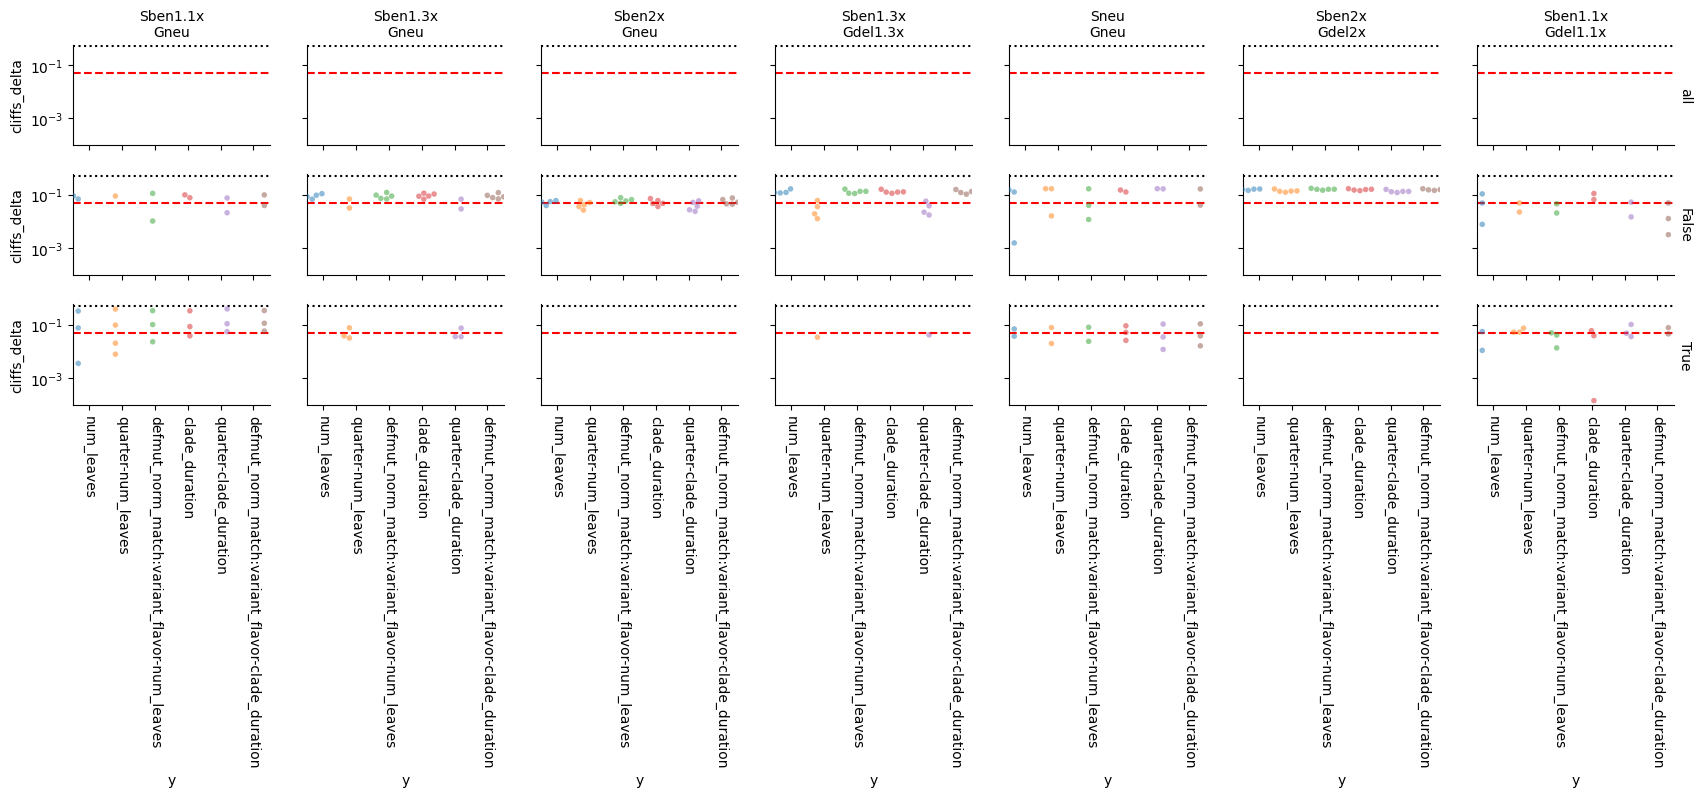

In [10]:
for y in "p_binom", "p_boot", "p_mw", "u_mw", "cliffs_delta":
    display(HTML(f"<h1>{y=}</h1>"))
    with tp.teed(
        sns.catplot,
        data=results_df[results_df["trt_hsurf_bits"] == 0],
        y=y,
        x="y",
        col="trt_name_",
        row="label",
        hue="y",
        legend=False,
        kind="swarm",
        dodge=True,
        margin_titles=True,
        alpha=0.5,
        height=1.5,
        aspect=1.6,
        size=4,
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("log")
            ax.axhline(0.5, color="black", linestyle=":")
            ax.axhline(0.05, color="red", linestyle="--")
            ax.tick_params(axis="x", rotation=-90)

        teed.tight_layout()
